**ALUMNO: SEBASTIAN VICTOR CARDENAS LUJAN**

# Carga de datos






In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
csv_file_path = '/content/drive/MyDrive/ProyectoFinal/Housing_DataSet.csv' # Reemplaza con la ruta de tu archivo CSV
df = pd.read_csv(csv_file_path)
display(df.head())

,size_m2,bedrooms,bathrooms,age,distance_city_center_km,floor,parking_spaces,has_elevator,neighborhood,property_type,condition,heating_type,price
0,114.901425,1,1,43,1.585631,7,0,1,C,house,good,electric,339242.2146
1,95.852071,2,1,39,8.446147,14,1,0,D,apartment,new,gas,275109.1321
2,119.430656,1,2,29,5.084709,17,1,0,B,studio,old,gas,365741.9224
3,145.690896,4,3,13,11.766039,10,1,0,B,studio,good,gas,478672.1242
4,92.975399,3,1,9,6.658342,1,1,0,D,studio,good,electric,280683.8890


# Duplicado de Datos

# Separacion de Train y Test


In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["price"])
y = df["price"]

# Dividimos: 80% entrenamiento, 20% prueba
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=1)

print("Train:", x_train.shape, "| Test:", x_test.shape)

Train: (16000, 12) | Test: (4000, 12)


# Limpieza train y test

In [ ]:
dup = x_train.duplicated().sum()
print(f"Duplicados en train: {dup}")

# Si hubiera, eliminamos la fila duplicada y su precio asociado
y_train = y_train.drop(x_train[x_train.duplicated()].index)
x_train = x_train.drop_duplicates()

Duplicados en train: 0


In [ ]:
nulos = (x_train.isnull().sum() / x_train.shape[0] * 100).round(2)
print("% de nulos por variable:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos.")

% de nulos por variable:
No hay valores nulos.


In [ ]:
dup = x_test.duplicated().sum()
print(f"Duplicados en test: {dup}")
# Eliminamos la fila duplicada y su precio asociado EN EL TEST
y_test = y_test.drop(x_test[x_test.duplicated()].index)
x_test = x_test.drop_duplicates()

Duplicados en test: 0


In [ ]:
nulos=(x_test.isnull().sum()/x_test.shape[0]*100).round(2)
print("% de nulos por variable:")
print(nulos[nulos>0] if nulos.sum()>0 else "No hay valores nulos.")

% de nulos por variable:
No hay valores nulos.


**Para variables cuantitativas**

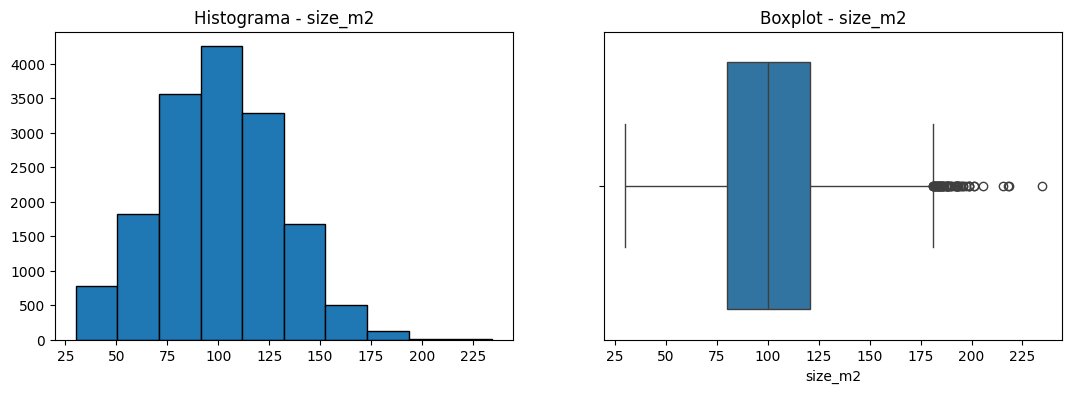

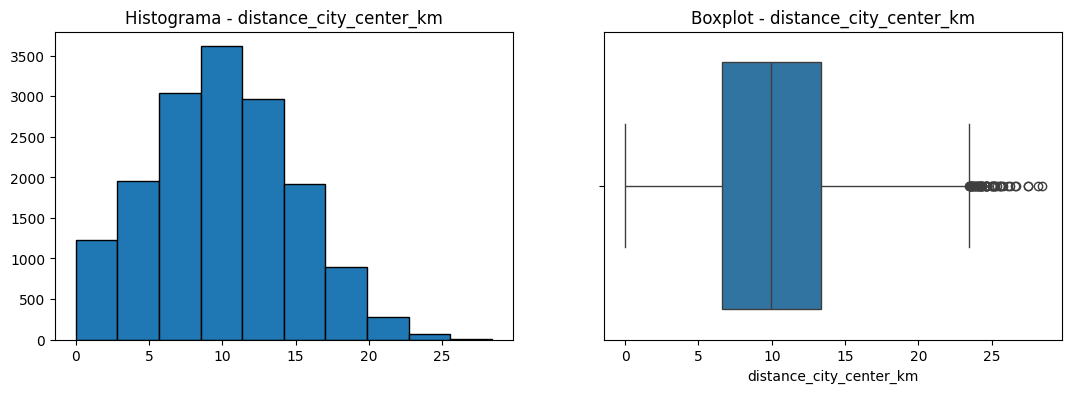

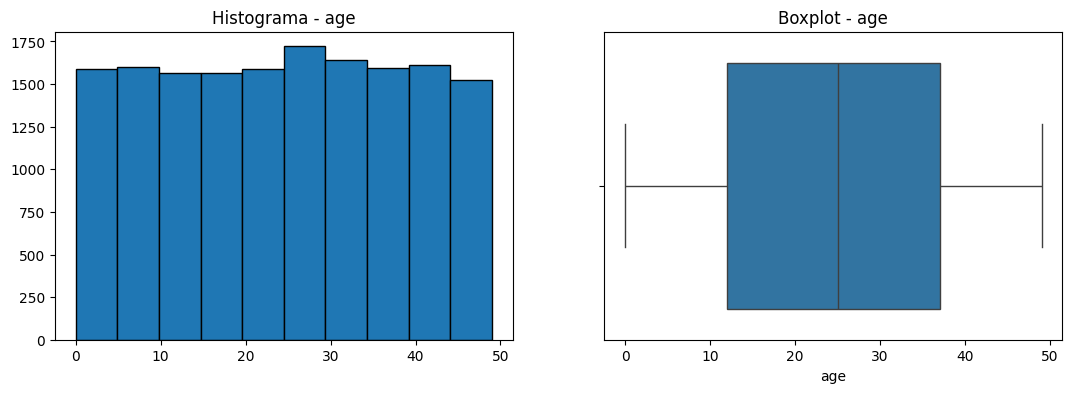

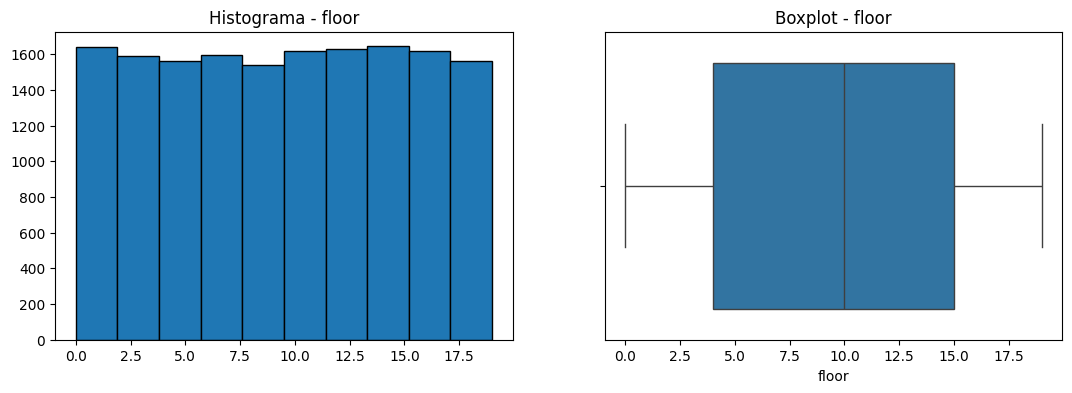

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizamos outliers SOLO en variables realmente continuas.
# has_elevator es binaria (0/1) y bedrooms/bathrooms/parking_spaces son discretas
# acotadas: no tiene sentido buscarles outliers, por eso las excluimos.
cols_num = ["size_m2", "distance_city_center_km", "age", "floor"]
porc_out = []

for col in cols_num:
    plt.figure(figsize=(13, 4))

    # Histograma: forma de la distribución
    plt.subplot(1, 2, 1)
    plt.title(f"Histograma - {col}")
    plt.hist(x_train[col], edgecolor="black")

    # Boxplot: los puntos fuera de los "bigotes" son outliers
    plt.subplot(1, 2, 2)
    plt.title(f"Boxplot - {col}")
    sns.boxplot(x=x_train[col], orient="h")
    plt.show()

    # Calculamos el % de outliers con el método IQR
    Q1, Q3 = x_train[col].quantile(0.25), x_train[col].quantile(0.75)
    IQR = Q3 - Q1
    LI, LS = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    pct = x_train[(x_train[col] < LI) | (x_train[col] > LS)].shape[0] / x_train.shape[0] * 100
    porc_out.append(round(pct, 2))

In [ ]:
pd.DataFrame({"Variable": cols_num, "% Outliers": porc_out}).sort_values("% Outliers", ascending=False)

,Variable,% Outliers
0,size_m2,0.40
1,distance_city_center_km,0.33
2,age,0.00
3,floor,0.00


In [ ]:
# Eliminamos outliers de las dos variables que los tienen (porcentaje muy bajo), usando limites IQR del TRAIN

for col in ["size_m2", "distance_city_center_km"]:
    Q1, Q3 = x_train[col].quantile(0.25), x_train[col].quantile(0.75)
    IQR = Q3 - Q1
    LI, LS = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    # Índices de las filas que NO son outliers (están dentro de los límites)
    filas_ok = x_train[(x_train[col] >= LI) & (x_train[col] <= LS)].index

    # Nos quedamos solo con esas filas, en x y en y a la vez
    x_train = x_train.loc[filas_ok]
    y_train = y_train.loc[filas_ok]

print("Train tras eliminar outliers:", x_train.shape)

Train tras eliminar outliers: (15884, 12)


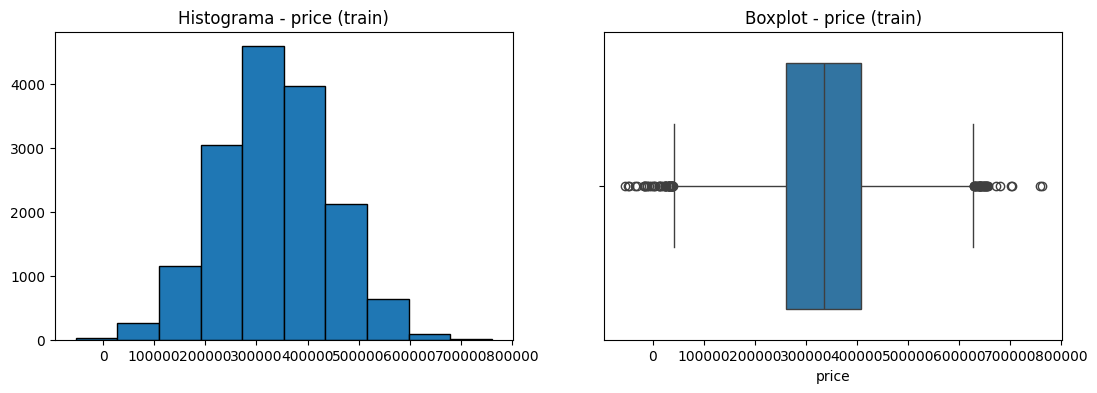

count     15884.000000
mean     334976.468238
std      107543.162632
min      -53770.927570
25%      261686.086775
50%      334728.204050
75%      408254.937075
max      761063.461700
Name: price, dtype: float64


In [ ]:
plt.figure(figsize=(13, 4))
# Histograma del precio
plt.subplot(1, 2, 1)
plt.title("Histograma - price (train)")
plt.hist(y_train, edgecolor="black")
# Boxplot del precio
plt.subplot(1, 2, 2)
plt.title("Boxplot - price (train)")
sns.boxplot(x=y_train, orient="h")
plt.show()
# Estadísticas básicas
print(y_train.describe())

In [ ]:
# Eliminamos precios imposibles (<= 0) en el TRAIN
idx_train = y_train[y_train > 0].index
x_train = x_train.loc[idx_train]
y_train = y_train.loc[idx_train]

# Y también en el TEST (aquí sí, porque es un valor inválido, no un outlier)
idx_test = y_test[y_test > 0].index
x_test = x_test.loc[idx_test]
y_test = y_test.loc[idx_test]

print("Train:", x_train.shape, "| Test:", x_test.shape)

Train: (15871, 12) | Test: (3997, 12)


# Correlacion de variables

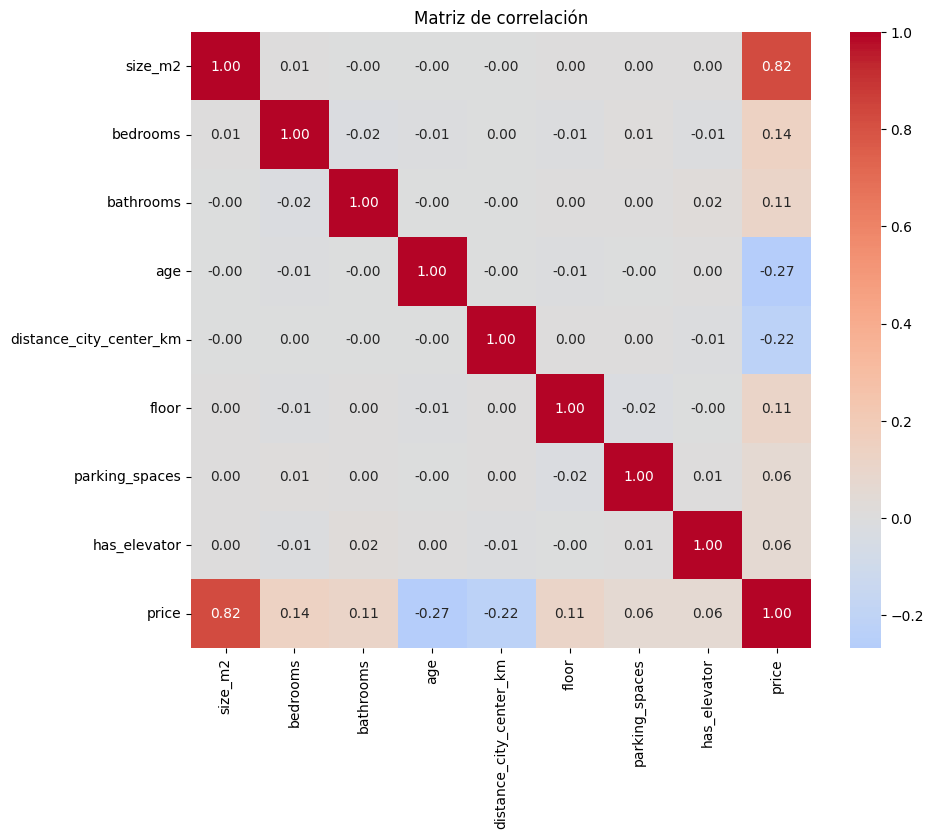

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_corr = x_train.select_dtypes(include="number").copy()
df_corr["price"] = y_train

# Mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [ ]:
# Correlación de cada variable con price, de mayor a menor
df_corr.corr()["price"].drop("price").sort_values(ascending=False)

,price
size_m2,0.819835
bedrooms,0.135984
bathrooms,0.109169
floor,0.109070
parking_spaces,0.059915
has_elevator,0.058887
distance_city_center_km,-0.221838
age,-0.267213


In [ ]:
import scipy.stats as scis

# Columnas cualitativas (tipo texto/objeto)
cols_cat = x_train.select_dtypes(include="object").columns

# Comparamos cada PAR de cualitativas
for i in cols_cat:
    for j in cols_cat:
        if i > j:   # evita repetir pares y comparar una variable consigo misma
            tabla = pd.crosstab(x_train[i], x_train[j])      # tabla de contingencia
            p = scis.chi2_contingency(tabla)[1]              # [1] = el p-valor
            relacion = "SÍ relacionadas" if p < 0.05 else "NO relacionadas"
            print(f"{i} - {j}: p-valor = {p:.4f} -> {relacion}")

neighborhood - condition: p-valor = 0.8180 -> NO relacionadas
neighborhood - heating_type: p-valor = 0.5157 -> NO relacionadas
property_type - neighborhood: p-valor = 0.7379 -> NO relacionadas
property_type - condition: p-valor = 0.4336 -> NO relacionadas
property_type - heating_type: p-valor = 0.8758 -> NO relacionadas
heating_type - condition: p-valor = 0.6912 -> NO relacionadas


# PRE procesamiento Variables Cualitativas

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# condition tiene orden: old < good < new
orden = [["old", "good", "new"]]   # de menor a mayor
oe = OrdinalEncoder(categories=orden)

x_train["condition"] = oe.fit_transform(x_train[["condition"]])
x_test["condition"]  = oe.transform(x_test[["condition"]])

In [ ]:
# Ya con condition convertida, solo quedan nominales para get_dummies
x_train = pd.get_dummies(x_train, drop_first=True, dtype="int")
x_test  = pd.get_dummies(x_test,  drop_first=True, dtype="int")
x_test  = x_test.reindex(columns=x_train.columns, fill_value=0)

# PRE procesamiento Variables Cuantitavias

In [ ]:
from sklearn.preprocessing import StandardScaler

# Creamos el escalador
sc = StandardScaler()

# TRAIN: fit_transform -> aprende media y desviación DEL TRAIN y transforma
x_train_sc = sc.fit_transform(x_train)
x_train_sc = pd.DataFrame(x_train_sc, columns=x_train.columns, index=x_train.index)

# TEST: solo transform -> usa la media y desviación YA aprendidas del train
x_test_sc = sc.transform(x_test)
x_test_sc = pd.DataFrame(x_test_sc, columns=x_test.columns, index=x_test.index)

x_train_sc.head()

,size_m2,bedrooms,bathrooms,age,distance_city_center_km,floor,parking_spaces,has_elevator,condition,neighborhood_B,neighborhood_C,neighborhood_D,property_type_house,property_type_studio,heating_type_gas,heating_type_none
7013,0.748854,0.000894,-1.212345,1.501042,-0.866920,-0.260001,-1.228497,-0.999685,-1.243422,1.746651,-0.569031,-0.591151,-0.713499,1.423757,-0.704569,1.418502
7766,2.661931,-0.708294,-1.212345,-1.223363,1.352198,-0.086852,-1.228497,-0.999685,-0.010795,-0.572524,-0.569031,1.691614,-0.713499,1.423757,-0.704569,1.418502
5910,0.516890,-0.708294,0.013595,1.710612,0.803414,-1.125743,-0.001855,-0.999685,-1.243422,-0.572524,-0.569031,1.691614,-0.713499,-0.702367,-0.704569,1.418502
7020,2.098162,0.710082,0.013595,-1.642503,-1.242685,-0.606298,-1.228497,-0.999685,1.221831,-0.572524,-0.569031,-0.591151,-0.713499,-0.702367,-0.704569,-0.704969
16952,-0.091741,0.000894,0.013595,1.501042,-1.729500,1.125186,1.224787,-0.999685,-1.243422,-0.572524,1.757372,-0.591151,-0.713499,-0.702367,1.419308,-0.704969


# Modelo de Regresion

In [ ]:
from sklearn.linear_model import LinearRegression

# Creamos el modelo de regresión lineal
lr = LinearRegression()

# Entrenamos: el modelo aprende la relación entre las x (escaladas) y el precio
lr.fit(x_train_sc, y_train)

print("Modelo entrenado correctamente.")
print("Intercepto:", round(lr.intercept_, 2))

Modelo entrenado correctamente.
Intercepto: 335270.36


In [ ]:
import statsmodels.api as sm

# statsmodels necesita que le agregues manualmente la constante (el intercepto)
x_train_const = sm.add_constant(x_train_sc)

# Ajustamos el modelo OLS (Ordinary Least Squares = regresión lineal por mínimos cuadrados)
modelo_ols = sm.OLS(y_train, x_train_const).fit()

# Mostramos el resumen completo
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                 2.735e+04
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        08:21:50   Log-Likelihood:            -1.7972e+05
No. Observations:               15871   AIC:                         3.595e+05
Df Residuals:                   15854   BIC:                         3.596e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    3

todas tiene un p-value menor al 0.05, son variables significativas y esta bien la inclusion en el modelo

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predicciones sobre el TEST (datos que el modelo nunca vio durante el entrenamiento)
y_pred = lr.predict(x_test_sc)

# --- Métricas ---
r2   = r2_score(y_test, y_pred)                 # R²: % de varianza explicada
mae  = mean_absolute_error(y_test, y_pred)      # MAE: error absoluto medio
ecm  = mean_squared_error(y_test, y_pred)       # ECM (MSE): error cuadrático medio
rmse = np.sqrt(ecm)                             # RMSE: raíz del ECM
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100   # MAPE: error porcentual

print(f"R²    : {r2:.4f}   ({r2*100:.2f}% de la varianza explicada)")
print(f"MAE   : {mae:,.2f}")
print(f"ECM   : {ecm:,.2f}   (MSE)")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")

R²    : 0.9637   (96.37% de la varianza explicada)
MAE   : 16,221.40
ECM   : 415,944,835.63   (MSE)
RMSE  : 20,394.73
MAPE  : 5.93%


# **VALIDACION CRUZADA**

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# --- R² en 10 folds ---
cv_r2 = cross_val_score(lr, x_train_sc, y_train, scoring="r2", cv=10)
print("R² por fold:", np.round(cv_r2, 4))
print(f"R² promedio: {cv_r2.mean():.4f}  (+/- {cv_r2.std():.4f})")

R² por fold: [0.9678 0.9676 0.964  0.9652 0.9624 0.9666 0.9641 0.9666 0.963  0.9617]
R² promedio: 0.9649  (+/- 0.0021)


In [ ]:
# --- RMSE en 10 folds ---
# sklearn da el MSE en negativo (por convención), por eso el -1 y luego la raíz
cv_mse = -cross_val_score(lr, x_train_sc, y_train, scoring="neg_mean_squared_error", cv=10)
print("RMSE por fold:", np.round(np.sqrt(cv_mse), 2))
print(f"RMSE promedio: {np.sqrt(cv_mse).mean():,.2f}")

RMSE por fold: [19233.27 19758.58 20012.2  20015.67 20404.23 19876.18 20424.79 19718.18
 20549.81 20438.78]
RMSE promedio: 20,043.17


In [ ]:
# --- MAE en 10 folds ---
cv_mae = -cross_val_score(lr, x_train_sc, y_train, scoring="neg_mean_absolute_error", cv=10)
print("MAE por fold:", np.round(cv_mae, 2))
print(f"MAE promedio: {cv_mae.mean():,.2f}")

MAE por fold: [15312.54 15805.33 16035.41 15946.02 16159.15 16028.51 16206.46 15723.05
 16382.9  16314.41]
MAE promedio: 15,991.38


# **Graficas de Prediccion**

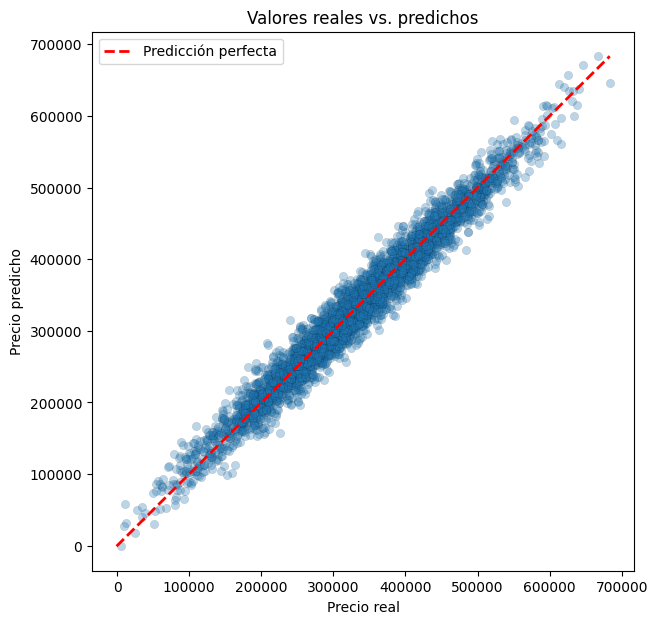

In [25]:
# Gráfico: valores reales vs. predichos
plt.figure(figsize=(7, 7))

# Cada punto es una vivienda: su precio real (eje x) vs. el predicho (eje y)
plt.scatter(y_test, y_pred, alpha=0.3, edgecolor="k", linewidth=0.2)

# Línea diagonal roja: la "predicción perfecta" (donde real = predicho)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Predicción perfecta")

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Valores reales vs. predichos")
plt.legend()
plt.show()